In [6]:
import pandas as pd
loops = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/loops_with_gene_info_genelevel_gtfgencode.csv", sep=",")
loops

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,...,delta_E1_anchor1,delta_E1_anchor2,ATAC_signal,status_slop,status_slop2,status_slop3,anchor1_id,anchor2_id,cre_categorization,gene_id
0,8,8,8,8,chr1,6105000,6110000,chr1,6240000,6245000,...,NaN,NaN,0.173772,shared_2.5kb,shared_10kb,shared_0kb,anchor1_8,anchor2_8,promoter-enhancer,RNF207
1,29,29,29,29,chr1,9782500,9787500,chr1,9862500,9867500,...,0.167823,-0.145121,0.051565,shared_2.5kb,shared_10kb,shared_0kb,anchor1_29,anchor2_29,enhancer-enhancer,CLSTN1
2,71,71,71,71,chr1,21222500,21227500,chr1,21572500,21577500,...,-0.006993,0.054035,0.057613,shared_2.5kb,shared_10kb,shared_0kb,anchor1_71,anchor2_71,enhancer-other,ECE1
3,77,77,77,77,chr1,22665000,22670000,chr1,22960000,22965000,...,-0.028926,0.044354,0.074445,shared_2.5kb,shared_10kb,shared_0kb,anchor1_77,anchor2_77,promoter-enhancer,EPHB2
4,78,78,78,78,chr1,22672500,22677500,chr1,22882500,22887500,...,-0.028926,-0.013898,0.080946,shared_2.5kb,shared_10kb,shared_0kb,anchor1_78,anchor2_78,enhancer-enhancer,EPHB2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1279,32165,32165,32165,32165,chr7,51412500,51417500,chr7,55602500,55607500,...,0.047841,0.067683,0.035898,gained_2.5kb,gained_10kb,gained_0kb,anchor1_32165,anchor2_32165,other-other,EGFR
1280,32208,32208,32208,32208,chr8,94812500,94817500,chr8,95022500,95027500,...,0.049483,-0.119102,0.040971,gained_2.5kb,gained_10kb,gained_0kb,anchor1_32208,anchor2_32208,promoter-enhancer,CCNE2
1281,32213,32213,32213,32213,chr8,122735000,122740000,chr8,123060000,123065000,...,-0.049312,-0.056527,0.039866,gained_2.5kb,gained_10kb,gained_0kb,anchor1_32213,anchor2_32213,enhancer-enhancer,ZHX2
1282,32230,32230,32230,32230,chr9,33582500,33587500,chr9,38552500,38557500,...,0.042401,-0.051918,0.024280,gained_2.5kb,gained_10kb,gained_0kb,anchor1_32230,anchor2_32230,other-other,TPM2


/tmp/ipykernel_1919525/2836320254.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


<Figure size 800x600 with 0 Axes>

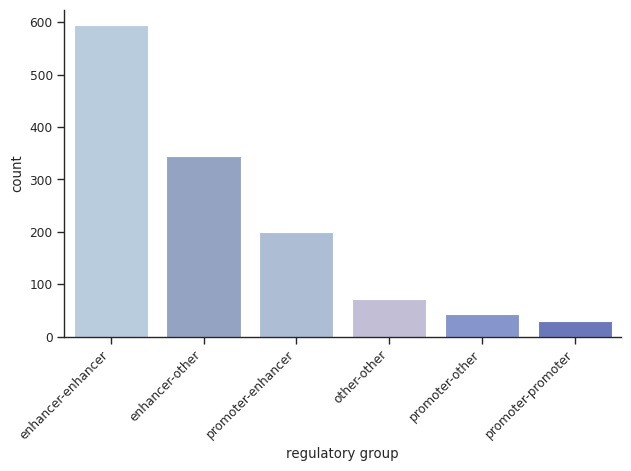

<Figure size 800x600 with 0 Axes>

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(
    style="ticks",
    rc={"axes.spines.top": False, "axes.spines.right": False}
)
sns.set_context('paper')

custom_palette = [
    "#b3cde3",  # pastel blue (like Peakachu)
    "#8da0cb",  # mid blue (like Mustache)
    "#a6bddb",  # muted blue
    "#bebada",  # blue-lavender
    "#7b8ed9",  # strong blue
    "#5e6ec8",  # deep blue-purple (like Cooltools)
]
sns.set_palette(custom_palette)

cre_counts = loops["cre_categorization"].value_counts().reset_index()
cre_counts.columns = ["cre_categorization", "count"]

ax = sns.barplot(
    data=cre_counts,   # DataFrame as source
    x="cre_categorization",
    y="count",
    palette=custom_palette
)

ax.set_ylabel("count")
ax.set_xlabel("regulatory group")
plt.xticks(rotation=45, ha="right")


plt.tight_layout()
plt.figure(figsize=(8, 6))

In [8]:
loops = loops.dropna(subset=["start1", "end1", "start2", "end2"])
loops[["start1", "end1", "start2", "end2"]] = loops[["start1", "end1", "start2", "end2"]].astype(int)
loops=loops[["chr1", "start1", "end1", "chr2", "start2", "end2"]]

In [9]:
loops

,chr1,start1,end1,chr2,start2,end2
0,chr1,6105000,6110000,chr1,6240000,6245000
1,chr1,9782500,9787500,chr1,9862500,9867500
2,chr1,21222500,21227500,chr1,21572500,21577500
3,chr1,22665000,22670000,chr1,22960000,22965000
4,chr1,22672500,22677500,chr1,22882500,22887500
...,...,...,...,...,...,...
1279,chr7,51412500,51417500,chr7,55602500,55607500
1280,chr8,94812500,94817500,chr8,95022500,95027500
1281,chr8,122735000,122740000,chr8,123060000,123065000
1282,chr9,33582500,33587500,chr9,38552500,38557500


In [10]:
loops.to_csv("loops_gtfgencode_igv.bedpe", sep="\t", index=False)

In [11]:
import pandas as pd
loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv", sep=",", usecols=["chr1", "start1", "end1", "chr2","start2", "end2"])
loops.to_csv("all_loops.bedpe", sep="\t", index=False)